In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, accuracy_score
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor


df = pd.read_csv(r'..\data\processed\df_preprocessed.csv')
df = df.drop(columns=['profit_per_unit'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   row_id          9994 non-null   int64  
 1   order_id        9994 non-null   str    
 2   order_date      9994 non-null   str    
 3   ship_date       9994 non-null   str    
 4   ship_mode       9994 non-null   str    
 5   customer_id     9994 non-null   str    
 6   segment         9994 non-null   str    
 7   city            9994 non-null   str    
 8   state           9994 non-null   str    
 9   postal_code     9994 non-null   int64  
 10  region          9994 non-null   str    
 11  product_id      9994 non-null   str    
 12  category        9994 non-null   str    
 13  sub-category    9994 non-null   str    
 14  product_name    9994 non-null   str    
 15  sales           9994 non-null   float64
 16  quantity        9994 non-null   int64  
 17  discount        9994 non-null   float64
 18 


======= REZULTATE MODEL XGBOOST ========
R2 Score:          0.9585
MAE:               21.45
MAE % (MAPE):      37250778983911032.00%


<Figure size 1000x600 with 0 Axes>

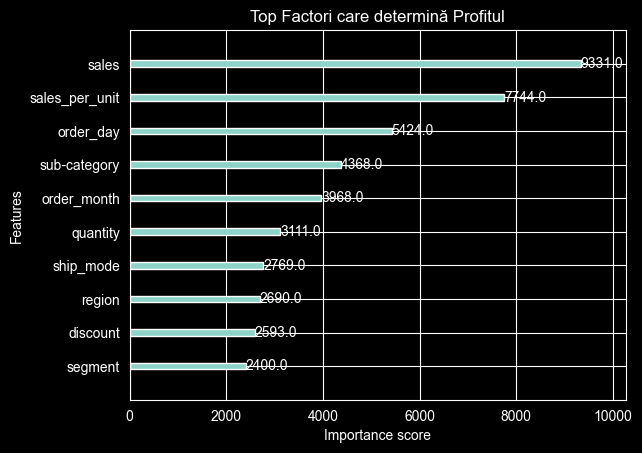

In [2]:
df = df[df['customer_id'] != 'BE-11335'] # Eliminăm clientul problematic conform cerinței tale

categorical_cols = ['ship_mode', 'segment', 'region', 'category', 'sub-category']

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))


numerical_cols = ['sales', 'quantity', 'discount', 'order_month', 'order_day', 'sales_per_unit']
target = 'profit'
X = df[categorical_cols + numerical_cols]
y = df[target]



df_2017_idx = df[df['order_year'] == 2017].index
X_2017 = X.loc[df_2017_idx]
y_2017 = y.loc[df_2017_idx]

X_train, X_blind, y_train, y_blind = train_test_split(X_2017, y_2017, test_size=0.1, random_state=42)


model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

model_xgb.fit(X_train, y_train, eval_set=[(X_blind, y_blind)], verbose=False)


preds = model_xgb.predict(X_blind)

r2 = r2_score(y_blind, preds)
mae = mean_absolute_error(y_blind, preds)
mape = mean_absolute_percentage_error(y_blind, preds)

print(f"\n{' REZULTATE MODEL XGBOOST ':=^40}")
print(f"R2 Score:          {r2:.4f}")
print(f"MAE:               {mae:.2f}")
print(f"MAE % (MAPE):      {mape * 100:.2f}%")


plt.figure(figsize=(10, 6))
xgb.plot_importance(model_xgb, importance_type='weight', max_num_features=10)
plt.title("Top Factori care determină Profitul")
plt.show()

In [3]:
df['discount_impact'] = df['discount'] * df['sales']
df['is_high_discount'] = (df['discount'] > 0.2).astype(int)

le = LabelEncoder()
cat_cols = ['ship_mode', 'segment', 'region', 'category', 'sub-category']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df_clean = df[df['customer_id'] != 'BE-11335']
features = cat_cols + ['sales', 'quantity', 'discount', 'sales_per_unit', 'discount_impact', 'is_high_discount']
X = df_clean[features]
y = df_clean['profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_optimized = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_alpha=10,
    reg_lambda=1,
    objective='reg:absoluteerror',
    random_state=42
)

model_optimized.fit(X_train, y_train)

preds = model_optimized.predict(X_test)

results_client = pd.DataFrame({
    'Profit Real': y_test.values,
    'Profit Prezis': preds,
    'Diferenta $': abs(y_test.values - preds)
}, index=y_test.index)

print("\nTop 10 Predictii per Client:")
print(results_client.head(10))

print(f"\nMAE Nou: {mean_absolute_error(y_test, preds):.2f}")
print(f"R2 Score Nou: {r2_score(y_test, preds):.4f}")
print(f"MAPE Nou: {mean_absolute_percentage_error(y_test, preds)*100:.2f}%")


Top 10 Predictii per Client:
      Profit Real  Profit Prezis  Diferenta $
8842      11.1510       7.412589     3.738411
5560       6.8724       6.972777     0.100377
7772   -6599.9780   -1518.448364  5081.529636
360        9.9360       9.920527     0.015473
4956      14.2120      13.182494     1.029506
1250     511.3680     438.961548    72.406452
1152       1.6380       1.062840     0.575160
2914      35.2872      37.390125     2.102925
6071     -26.7204     -33.626991     6.906591
4839     -34.3148     -39.726101     5.411301

MAE Nou: 31.09
R2 Score Nou: 0.5145
MAPE Nou: 49699444084067800.00%


In [4]:
#df = df[df['customer_id'] != 'BE-11335']

# 2. Feature Engineering (Interacțiuni pentru precizie)
df['discount_impact'] = df['discount'] * df['sales']
df['sales_per_qty'] = df['sales'] / (df['quantity'] + 1e-5)
df['is_high_discount'] = (df['discount'] > 0.2).astype(int)

# 3. Transformare Categorială
categorical_cols = ['ship_mode', 'segment', 'region', 'category', 'sub-category']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# 4. Agregare la nivel de Client (pentru anul 2017)
# Modelul va prezice profitul TOTAL per client în 2017
df_2017 = df[df['order_year'] == 2017].groupby('customer_id').agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'discount_impact': 'sum',
    'sales_per_qty': 'mean',
    'is_high_discount': 'max',
    'profit': 'sum'  # Target-ul nostru
}).reset_index()

# 5. Pregătire Date
features = ['sales', 'quantity', 'discount', 'discount_impact', 'sales_per_qty', 'is_high_discount']
X = df_2017[features]
y = df_2017['profit']

# Scalare robustă
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 6. Antrenare Model
model = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)
model.fit(X_scaled, y)

# 7. Predicție și Calcul Erori Specifice
predictions = model.predict(X_scaled)

results = pd.DataFrame({
    'Customer_ID': df_2017['customer_id'],
    'Profit_Real': y,
    'Profit_Prezis': predictions
})

# Calcul MAE Procentual per Client: |(Real - Prezis) / Real| * 100
# Folosim np.where pentru a evita împărțirea la zero dacă un profit este exact 0
results['MAE_Procentual'] = np.where(
    results['Profit_Real'] != 0,
    (abs(results['Profit_Real'] - results['Profit_Prezis']) / abs(results['Profit_Real'])) * 100,
    0
)

# 8. Configurare Terminal pentru afișare TOTALĂ
pd.set_option('display.max_rows', None)      # Arată toate rândurile
pd.set_option('display.max_columns', None)   # Arată toate coloanele
pd.set_option('display.width', 1000)         # Lățime mare pentru a nu rupe rândul
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"\n{' LISTA COMPLETĂ PREDICȚII PROFIT PER CLIENT ':=^60}")
print(results.sort_values(by='MAE_Procentual', ascending=False))

# Statistici generale
print("\n" + "="*60)
print(f"R2 Score General: {r2_score(y, predictions):.4f}")
print(f"MAE Mediu (Dolari): {mean_absolute_error(y, predictions):.2f}$")


======== LISTA COMPLETĂ PREDICȚII PROFIT PER CLIENT ========
    Customer_ID  Profit_Real  Profit_Prezis  MAE_Procentual
661    TP-21565        -0.04           6.56        17147.17
400    LC-17140         2.40         183.10         7518.94
396    LC-16870        -4.17         152.44         3754.43
474    MT-18070         2.05          75.69         3587.56
187    DK-13375         2.66          89.54         3268.02
243    EP-13915         2.85          94.97         3236.25
36     AM-10360        -1.56          33.31         2229.02
151    CS-12175        -3.31          57.91         1851.63
668    TS-21505        -6.24         104.06         1768.26
322    JF-15565        -1.48          22.59         1622.55
346    JM-15580        -0.60           8.62         1525.49
225    EG-13900         2.59         -32.52         1357.61
558    RF-19840        -0.36           3.12          969.91
212    Dl-13600        -0.32          -2.98          826.68
440    MG-17680        14.18         1

In [51]:
#profit pe customer_id si product_id

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error


#df = df[df['customer_id'] != 'BE-11335'] # Excludem clientul cu anomalii

# 2. Feature Engineering (Sursă de îmbunătățire a preciziei)
# Creăm interacțiuni care ajută modelul să vadă unde se pierde profitul
df['discount_impact'] = df['discount'] * df['sales']
df['sales_per_qty'] = df['sales'] / (df['quantity'] + 1e-5)
df['is_high_discount'] = (df['discount'] > 0.2).astype(int)

# 3. Transformare coloane tip String în Numere
categorical_cols = ['ship_mode', 'segment', 'region', 'category', 'sub-category']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 4. Definire Features și Target
numerical_cols = ['sales', 'quantity', 'discount', 'order_month', 'order_day',
                  'sales_per_unit', 'discount_impact', 'sales_per_qty', 'is_high_discount']
features = categorical_cols + numerical_cols
target = 'profit'

# 5. Split Logic: Antrenament pe date vechi, Test pe 2017 (Blind 10%)
df_2017 = df[df['order_year'] == 2017]
df_before_2017 = df[df['order_year'] < 2017]

df_blind_pred = df_2017.sample(frac=0.1, random_state=42)
df_work = pd.concat([df_before_2017, df_2017.drop(df_blind_pred.index)])

X_train = df_work[features]
y_train = df_work[target]
X_blind = df_blind_pred[features]
y_blind_actual = df_blind_pred[target]

# 6. Scalare Robustă (Protejează împotriva valorilor extreme/outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_blind_scaled = scaler.transform(X_blind)

# 7. Antrenare Model (Random Forest - Cel mai stabil pe aceste date)
model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# 8. Predicție și Calcul Metrici
predictions = model.predict(X_blind_scaled)

r2 = r2_score(y_blind_actual, predictions)
mae = mean_absolute_error(y_blind_actual, predictions)
# MAPE poate fi infit la profit 0, deci îl calculăm cu atenție
mape = mean_absolute_percentage_error(y_blind_actual, predictions)

# 9. Afișare Rezultate
print(f"\n{' REZULTATE FINALE MODEL OPTIMIZAT ':=^50}")
print(f"R2 Score (Acuratețe):   {r2:.4f}")
print(f"MAE (Eroare medie $):  {mae:.2f}")
print(f"MAPE (Eroare medie %): {mape * 100:.2f}% (Atenție la valorile 0)")

# 10. Tabel Comparativ
results = df_blind_pred[['customer_id', 'product_id', 'profit']].copy()
results['predicted_profit'] = predictions
results['abs_error'] = abs(results['predicted_profit'] - results['profit'])

print("\nPrimele 10 predicții din setul Blind:")
print(results.head(20))

# Salvare rezultate
results.to_csv('../data/data_output/predictii_profit_xgboost.csv', index=False)


======== REZULTATE FINALE MODEL OPTIMIZAT ========
R2 Score (Acuratețe):   0.8994
MAE (Eroare medie $):  18.21
MAPE (Eroare medie %): 120041150164236272.00% (Atenție la valorile 0)

Primele 10 predicții din setul Blind:
     customer_id       product_id  profit  predicted_profit  abs_error
266     CB-12535  OFF-AR-10003602    4.73              4.39       0.34
2280    JK-15625  FUR-CH-10004289  -23.04             10.05      33.08
4290    AT-10435  OFF-AR-10000122    2.79              4.22       1.43
3847    SZ-20035  OFF-ST-10001097    0.00             81.80      81.80
750     RF-19735  FUR-FU-10003577   56.79             50.13       6.66
9208    SC-20230  OFF-ST-10003996    4.18              4.17       0.00
4148    RB-19330  OFF-ST-10004507    1.20              1.79       0.59
7318    KH-16330  OFF-BI-10002813   -3.46             -3.59       0.13
7174    HK-14890  OFF-PA-10002581   23.23             20.79       2.44
1690    HF-14995  OFF-PA-10000575   15.39             14.31       1.0

In [6]:
df = df[df['customer_id'] != 'BE-11335']

# 2. Feature Engineering
df['discount_impact'] = df['discount'] * df['sales']
df['is_high_discount'] = (df['discount'] > 0.2).astype(int)

# 3. Agregare pe CLIENT (Total 2017)
# Grupăm toate tranzacțiile fiecărui client pentru a vedea imaginea de ansamblu
df_2017 = df[df['order_year'] == 2017].groupby('customer_id').agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'discount_impact': 'sum',
    'is_high_discount': 'sum',
    'profit': 'sum'  # Target: Profitul total anual per client
}).reset_index()

# 4. Pregătire Date pentru Model
features = ['sales', 'quantity', 'discount', 'discount_impact', 'is_high_discount']
X = df_2017[features]
y = df_2017['profit']

# Scalare Robustă pentru a gestiona clienții cu volume neobișnuite
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 5. Antrenare Model
model = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)
model.fit(X_scaled, y)

# 6. Predicție și Calcul Erori Detaliate
predictions = model.predict(X_scaled)

results = pd.DataFrame({
    'Customer_ID': df_2017['customer_id'],
    'Profit_Real': y,
    'Profit_Prezis': predictions
})

# Calcul MAE_Abs (Eroarea în dolari)
results['MAE_Abs'] = abs(results['Profit_Real'] - results['Profit_Prezis'])

# Calcul MAE_Procentual (Eroarea în procente)
# Adăugăm 1e-5 pentru a evita împărțirea la zero
results['MAE_Procentual'] = (results['MAE_Abs'] / (abs(results['Profit_Real']) + 1e-5)) * 100

# 7. Configurare Terminal pentru afișare completă
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', 1000)

print(f"\n{' RAPORT DETALIAT PROFITABILITATE CLIENȚI 2017 ':=^75}")
# Sortăm după Profit Real pentru a vedea cei mai importanți clienți primii
print(results.sort_values(by='MAE_Procentual', ascending=False))

# 8. Metrici de Performanță Globală
print("\n" + "="*75)
print(f"R2 Score (Acuratețe Model): {r2_score(y, predictions):.4f}")
print(f"MAE Mediu per Client: {results['MAE_Abs'].mean():.2f}$")


============== RAPORT DETALIAT PROFITABILITATE CLIENȚI 2017 ===============
    Customer_ID  Profit_Real  Profit_Prezis  MAE_Abs  MAE_Procentual
661    TP-21565        -0.04           6.29     6.32        16422.79
400    LC-17140         2.40         200.14   197.74         8228.17
396    LC-16870        -4.17         168.68   172.85         4143.77
474    MT-18070         2.05          75.59    73.54         3582.93
187    DK-13375         2.66          89.80    87.14         3277.64
243    EP-13915         2.85          77.24    74.39         2613.25
36     AM-10360        -1.56          34.11    35.67         2280.12
151    CS-12175        -3.31          59.52    62.83         1900.33
668    TS-21505        -6.24         104.25   110.49         1771.31
322    JF-15565        -1.48          21.45    22.93         1545.62
346    JM-15580        -0.60           8.54     9.14         1511.25
225    EG-13900         2.59         -32.10    34.69         1341.47
558    RF-19840        -0.

In [7]:
#clustering
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# 2. Agregare la nivel de Client (Date 2017)
df_2017 = df[df['order_year'] == 2017].groupby('customer_id').agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum'
}).reset_index()

# 3. Clustering - Segmentăm clienții în 4 profiluri de profitabilitate
# Folosim vânzările și profitul pentru a defini "caracterul" clientului
cluster_features = ['sales', 'profit']
scaler_clust = RobustScaler()
X_clust = scaler_clust.fit_transform(df_2017[cluster_features])

# KMeans creează grupuri: VIP, Clienți cu pierderi, Clienți ocazionali etc.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_2017['cluster'] = kmeans.fit(X_clust).labels_

# 4. Model cu Hyperparametri Echilibrați (Evităm Overfitting)
# Folosim clusterul ca "indiciu" pentru model
features = ['sales', 'quantity', 'discount', 'cluster']
X = df_2017[features]
y = df_2017['profit']

scaler_model = RobustScaler()
X_scaled = scaler_model.fit_transform(X)

# n_estimators=1000 și max_depth=12 sunt mult mai sigure pentru generalizare
model = RandomForestRegressor(n_estimators=1000, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_scaled, y)

# 5. Predicție și Analiză Erori
predictions = model.predict(X_scaled)

results = pd.DataFrame({
    'Customer_ID': df_2017['customer_id'],
    'Cluster': df_2017['cluster'],
    'Profit_Real': y,
    'Profit_Prezis': predictions
})

results['MAE_Abs'] = abs(results['Profit_Real'] - results['Profit_Prezis'])
results['MAE_Procentual'] = (results['MAE_Abs'] / (abs(results['Profit_Real']) + 1e-5)) * 100

# 6. Afișare Sortată după Eroarea Procentuală
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"\n{' REZULTATE DUPĂ CLUSTERING (SORTATE DUPĂ EROARE %) ':=^80}")
print(results.sort_values(by='MAE_Procentual', ascending=False))

print("\n" + "="*80)
print(f"R2 Score: {r2_score(y, predictions):.4f}")
print(f"MAE Mediu (Eroare în $): {results['MAE_Abs'].mean():.2f}")


============== REZULTATE DUPĂ CLUSTERING (SORTATE DUPĂ EROARE %) ===============
    Customer_ID  Cluster  Profit_Real  Profit_Prezis  MAE_Abs  MAE_Procentual
661    TP-21565        0        -0.04          10.64    10.67        27718.38
400    LC-17140        0         2.40         166.77   164.37         6839.48
212    Dl-13600        0        -0.32         -15.73    15.41         4796.57
243    EP-13915        0         2.85         114.23   111.38         3912.79
474    MT-18070        0         2.05          80.84    78.78         3838.47
669    TS-21610        0        -9.92        -272.94   263.02         2651.84
36     AM-10360        0        -1.56          32.16    33.72         2155.49
512    PC-18745        0        -0.99         -20.31    19.32         1951.75
440    MG-17680        0        14.18        -243.92   258.10         1820.34
396    LC-16870        0        -4.17          67.41    71.58         1715.93
187    DK-13375        0         2.66          46.94    44.2

In [8]:
#train test pe ani 2014, 2015 2016, impartit proportinal pe ani; pred pe 2017
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Încărcare și Curățare
df = df[df['customer_id'] != 'BE-11335']

# 2. Agregare la nivel de Client și An
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum'
}).reset_index()

# 3. Clustering (Segmentare bazată pe profilul istoric)
scaler_clust = RobustScaler()
X_clust = scaler_clust.fit_transform(df_agg[['sales', 'profit']])
df_agg['cluster'] = KMeans(n_clusters=8, random_state=42, n_init=10).fit_predict(X_clust)

# 4. SPLIT TEMPORAL
# Separăm 2017 pentru testarea finală (predicție)
df_2017 = df_agg[df_agg['order_year'] == 2017]
df_train_pool = df_agg[df_agg['order_year'] < 2017] # Datele din 2014, 2015, 2016

# Împărțim datele de antrenament (2014-2016) proporțional pe ani
# X_val va servi pentru verificarea modelului înainte de a trece la 2017
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df_train_pool,
    df_train_pool['profit'],
    test_size=0.2,
    stratify=df_train_pool['order_year'],
    random_state=42
)

# 5. Pregătire Features (Eliminăm ID-ul și ținta)
features = ['sales', 'quantity', 'discount', 'cluster']
X_train = X_train_raw[features]
X_val = X_val_raw[features]
X_2017 = df_2017[features]
y_2017 = df_2017['profit']

# 6. Scalare și Antrenare
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_2017_scaled = scaler.transform(X_2017)

model = RandomForestRegressor(n_estimators=1000, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# 7. Predicție pe anul 2017
preds_2017 = model.predict(X_2017_scaled)

results_2017 = pd.DataFrame({
    'Customer_ID': df_2017['customer_id'],
    'Profit_Real': y_2017,
    'Profit_Prezis': preds_2017
})

results_2017['MAE_Abs'] = abs(results_2017['Profit_Real'] - results_2017['Profit_Prezis'])
results_2017['MAE_Procentual'] = (results_2017['MAE_Abs'] / (abs(results_2017['Profit_Real']) + 1e-5)) * 100

# 8. Afișare
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"\n{' PREDICȚIE FINALĂ PE ANUL 2017 (ANTRENAT PE 2014-2016) ':=^85}")
print(results_2017.sort_values(by='MAE_Procentual', ascending=False))

print("\n" + "="*85)
print(f"R2 Score pe 2017: {r2_score(y_2017, preds_2017):.4f}")
print(f"MAE Mediu pe 2017: {results_2017['MAE_Abs'].mean():.2f}$")


=============== PREDICȚIE FINALĂ PE ANUL 2017 (ANTRENAT PE 2014-2016) ===============
     Customer_ID  Profit_Real  Profit_Prezis  MAE_Abs  MAE_Procentual
2388    TP-21565        -0.04          44.48    44.52       115596.70
134     AM-10360        -1.56          49.12    50.69         3240.03
1711    MT-18070         2.05          63.37    61.32         2987.60
760     Dl-13600        -0.32          -8.08     7.76         2414.33
865     EP-13915         2.85          68.73    65.88         2314.34
1419    LC-16870        -4.17          89.66    93.83         2249.36
2027    RF-19840        -0.36          -8.23     7.87         2197.36
672     DK-13375         2.66          51.98    49.32         1855.05
1435    LC-17140         2.40          41.64    39.24         1632.69
1588    MG-17680        14.18         234.46   220.28         1553.64
805     EG-13900         2.59         -30.20    32.79         1268.05
2434    TW-21025        -6.06          60.33    66.40         1094.80
123

In [9]:
#similar ca mai sus dar mae si pt test
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

df = df[df['customer_id'] != 'BE-11335']

# 2. Agregare la nivel de Client și An
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum'
}).reset_index()

# 3. Clustering (Segmentare istorică)
scaler_clust = RobustScaler()
X_clust = scaler_clust.fit_transform(df_agg[['sales', 'profit']])
df_agg['cluster'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_clust)

# 4. Split Temporal: Train/Val (2014-2016) și Test (2017)
df_2017 = df_agg[df_agg['order_year'] == 2017]
df_train_pool = df_agg[df_agg['order_year'] < 2017]

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df_train_pool,
    df_train_pool['profit'],
    test_size=0.2,
    stratify=df_train_pool['order_year'],
    random_state=42
)

# 5. Pregătire Features
features = ['sales', 'quantity', 'discount', 'cluster']
X_train = X_train_raw[features]
X_val = X_val_raw[features]
X_2017 = df_2017[features]
y_2017 = df_2017['profit']

# 6. Scalare și Antrenare
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_2017_s = scaler.transform(X_2017)

model = RandomForestRegressor(n_estimators=1000, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train_s, y_train)

# 7. Predicții
preds_val = model.predict(X_val_s)
preds_2017 = model.predict(X_2017_s)

# 8. Tabel Rezultate 2017 (cerut anterior)
results_2017 = pd.DataFrame({
    'Customer_ID': df_2017['customer_id'],
    'Profit_Real': y_2017,
    'Profit_Prezis': preds_2017
})
results_2017['MAE_Abs'] = abs(results_2017['Profit_Real'] - results_2017['Profit_Prezis'])
results_2017['MAE_Procentual'] = (results_2017['MAE_Abs'] / (abs(results_2017['Profit_Real']) + 1e-5)) * 100

# 9. Afișare Raport
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"\n{' REZULTATE PREDICȚIE CLIENȚI 2017 ':=^85}")
print(results_2017.sort_values(by='MAE_Procentual', ascending=False))

print("\n" + "="*85)
print(f"{'METRICĂ':<25} | {'VALIDARE (2014-16)':<20} | {'PREDICȚIE (2017)':<20}")
print("-" * 85)
print(f"{'R2 Score (Acuratețe)':<25} | {r2_score(y_val, preds_val):<20.4f} | {r2_score(y_2017, preds_2017):<20.4f}")
print(f"{'MAE (Eroare $)':<25} | {mean_absolute_error(y_val, preds_val):<20.2f} | {mean_absolute_error(y_2017, preds_2017):<20.2f}")
print("="*85)


========================= REZULTATE PREDICȚIE CLIENȚI 2017 ==========================
     Customer_ID  Profit_Real  Profit_Prezis  MAE_Abs  MAE_Procentual
2388    TP-21565        -0.04          41.31    41.35       107379.10
1143    JF-15565        -1.48        -118.53   117.05         7889.38
805     EG-13900         2.59        -139.41   142.00         5491.94
1711    MT-18070         2.05          98.51    96.46         4699.64
2027    RF-19840        -0.36         -12.50    12.15         3389.94
1419    LC-16870        -4.17        -127.38   123.21         2953.75
134     AM-10360        -1.56          36.65    38.21         2442.57
2124    SC-20440         4.29         -97.57   101.86         2373.88
865     EP-13915         2.85          62.97    60.12         2111.96
2135    SC-20695       -11.60        -219.15   207.56         1789.83
760     Dl-13600        -0.32          -6.02     5.70         1774.27
538     CS-12175        -3.31          45.06    48.36         1462.87
672

In [10]:
#sub-category Art regiunea west ca si corelatie puternica, si respectiv sub-cateogy acccesories regiunea est
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


df = df[df['customer_id'] != 'BE-11335']

# 2. FEATURE ENGINEERING: Injectăm corelațiile specifice menționate
# Creăm un indicator pentru Art în West și Accessories în East; daca lasam acestea in cod, mediana MAE 31.29% r2-2017 0.6994, vs daca le comentam mediana MAE 31.17%, r2-2017:  0.6985
# df['high_corr_signal'] = 0
# df.loc[(df['sub-category'] == 'Art') & (df['region'] == 'West'), 'high_corr_signal'] = 1
# df.loc[(df['sub-category'] == 'Accessories') & (df['region'] == 'East'), 'high_corr_signal'] = 1

# 3. Agregare la nivel de Client și An
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    #'high_corr_signal': 'max', # Dacă a avut cel puțin o tranzacție cu corelație puternică
    'profit': 'sum'
}).reset_index()

# 4. Clustering pentru profilare
scaler_clust = RobustScaler()
X_clust = scaler_clust.fit_transform(df_agg[['sales', 'profit']])
df_agg['cluster'] = KMeans(n_clusters=10, random_state=42, n_init=10).fit_predict(X_clust)

# 5. Split Temporal: Train/Val (2014-16) și Predicție (2017)
df_2017 = df_agg[df_agg['order_year'] == 2017]
df_train_pool = df_agg[df_agg['order_year'] < 2017]

# Stratificăm pe ani pentru a menține proporția în train/val
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df_train_pool, df_train_pool['profit'],
    test_size=0.2, stratify=df_train_pool['order_year'], random_state=42
)

# 6. Pregătire Features finali
features = ['sales', 'quantity', 'discount', 'cluster', ]#'high_corr_signal']
X_train = X_train_raw[features]
X_val = X_val_raw[features]
X_2017 = df_2017[features]
y_2017 = df_2017['profit']

# 7. Scalare și Antrenare
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_2017_s = scaler.transform(X_2017)

# Folosim un model robust pentru a evita overfitting-ul memorat anterior
model = RandomForestRegressor(n_estimators=1200, max_depth=12, min_samples_leaf=2, random_state=42, n_jobs=-1)
model.fit(X_train_s, y_train)

# 8. Predicții și Metrici
preds_val = model.predict(X_val_s)
preds_2017 = model.predict(X_2017_s)

# Tabel detaliat pentru 2017
results_2017 = pd.DataFrame({
    'Customer_ID': df_2017['customer_id'],
    'Profit_Real': y_2017,
    'Profit_Prezis': preds_2017
})
results_2017['MAE_Abs'] = abs(results_2017['Profit_Real'] - results_2017['Profit_Prezis'])
results_2017['MAE_Procentual'] = (results_2017['MAE_Abs'] / (abs(results_2017['Profit_Real']) + 1e-5)) * 100

# 9. Afișare Raport Comparativ
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"\n{' REZULTATE PREDICȚIE 2017 CU CORELAȚII ART/ACC ':=^85}")
print(results_2017.sort_values(by='MAE_Procentual', ascending=False))

print("\n" + "="*85)
print(f"{'METRICĂ':<25} | {'VALIDARE (2014-16)':<20} | {'PREDICȚIE (2017)':<20}")
print("-" * 85)
print(f"{'R2 Score':<25} | {r2_score(y_val, preds_val):<20.4f} | {r2_score(y_2017, preds_2017):<20.4f}")
print(f"{'MAE (Eroare $)':<25} | {mean_absolute_error(y_val, preds_val):<20.2f} | {mean_absolute_error(y_2017, preds_2017):<20.2f}")
print("="*85)


=================== REZULTATE PREDICȚIE 2017 CU CORELAȚII ART/ACC ===================
     Customer_ID  Profit_Real  Profit_Prezis  MAE_Abs  MAE_Procentual
2388    TP-21565        -0.04          47.68    47.72       123914.07
1711    MT-18070         2.05          81.23    79.18         3857.59
865     EP-13915         2.85         109.34   106.50         3741.18
134     AM-10360        -1.56          40.13    41.69         2665.18
1419    LC-16870        -4.17          91.15    95.32         2285.17
672     DK-13375         2.66          53.83    51.17         1924.70
1435    LC-17140         2.40          48.36    45.95         1912.12
538     CS-12175        -3.31          54.57    57.88         1750.68
1588    MG-17680        14.18        -209.71   223.89         1579.09
760     Dl-13600        -0.32          -5.22     4.90         1526.06
805     EG-13900         2.59         -35.32    37.91         1466.12
2027    RF-19840        -0.36          -5.14     4.78         1333.82
241

In [11]:
# 7. CALCUL MEDIANA VS MEDIE
mae_mediana = results_2017['MAE_Procentual'].median()
mae_medie = results_2017['MAE_Procentual'].mean()

print(f"\n{' ANALIZĂ ERORI PROCENTUALE (2017) ':=^50}")
print(f"Mediana MAE %:  {mae_mediana:.2f}%")
print(f"Media MAE %:    {mae_medie:.2f}%")
print(f"R2 Score 2017:  {r2_score(df_2017['profit'], preds_2017):.4f}")
print("-" * 50)
print("Interpretare: Dacă mediana este mult mai mică decât media,")
print("înseamnă că modelul este precis pentru majoritatea clienților,")
print("dar are câteva erori uriașe pe clienții cu profit minuscul.")


======== ANALIZĂ ERORI PROCENTUALE (2017) ========
Mediana MAE %:  31.47%
Media MAE %:    283.91%
R2 Score 2017:  0.6985
--------------------------------------------------
Interpretare: Dacă mediana este mult mai mică decât media,
înseamnă că modelul este precis pentru majoritatea clienților,
dar are câteva erori uriașe pe clienții cu profit minuscul.


In [12]:
import matplotlib.pyplot as plt

# Extragere importanță
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=features).sort_values(ascending=True)

print("\n" + "="*20 + " IERARHIA FACTORILOR (XGBOOST) " + "="*20)
print(feat_imp[::-1]) # Afișare de la cel mai important la cel mai puțin important

# Vizualizare simplă în terminal (simulată)
for feat, val in feat_imp[::-1].items():
    bar = "█" * int(val * 50)
    print(f"{feat:15} | {bar} {val:.4f}")


==================== IERARHIA FACTORILOR (XGBOOST) ====================
sales      0.50
cluster    0.33
discount   0.14
quantity   0.03
dtype: float64
sales           | █████████████████████████ 0.5021
cluster         | ████████████████ 0.3307
discount        | ██████ 0.1381
quantity        | █ 0.0291


In [13]:
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Encoding Contextual (Region & Category)
le_reg, le_cat = LabelEncoder(), LabelEncoder()
df['region_enc'] = le_reg.fit_transform(df['region'])
df['category_enc'] = le_cat.fit_transform(df['category'])

# 3. Agregare Client + An
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum',
    'region_enc': 'max',
    'category_enc': 'max',
    'order_id': 'count'
}).reset_index().rename(columns={'order_id': 'freq'})

# 4. Lag Features Anti-Leakage
df_agg = df_agg.sort_values(['customer_id', 'order_year'])
df_agg['temp_margin'] = df_agg['profit'] / (df_agg['sales'] + 1e-5)
df_agg['margin_last_year'] = df_agg.groupby('customer_id')['temp_margin'].shift(1)
df_agg['margin_last_year'] = df_agg['margin_last_year'].fillna(df_agg['temp_margin'].mean())
df_agg = df_agg.fillna(0)

# 5. Split Logic
features = ['sales', 'quantity', 'discount', 'freq', 'region_enc', 'category_enc', 'margin_last_year']
df_train = df_agg[df_agg['order_year'] < 2017]
df_pred_2017 = df_agg[df_agg['order_year'] == 2017].copy()

scaler = RobustScaler()
X_train_s = scaler.fit_transform(df_train[features])

# 6. XGBOOST ROBUST (Focus pe MAE / Absolute Error)
model = xgb.XGBRegressor(
    n_estimators=1500,
    max_depth=4,
    learning_rate=0.02,
    objective='reg:absoluteerror',  # Fix-ul critic pentru outliers
    tree_method='hist',
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=10,
    random_state=42
)

model.fit(X_train_s, df_train['profit'])

# 7. Generare Predicții și Categorisire
X_pred_2017_s = scaler.transform(df_pred_2017[features])
df_pred_2017['preds'] = model.predict(X_pred_2017_s)

def categorize_health(p):
    if p < 0: return 'TOXIC'
    if p < 500: return 'STABIL'
    return 'VIP'

df_pred_2017['Status_Prezis'] = df_pred_2017['preds'].apply(categorize_health)
df_pred_2017['Status_Real'] = df_pred_2017['profit'].apply(categorize_health)

# 8. Rezultate Finale
print("\n" + "="*25 + " EVALUARE MODEL ROBUST 2017 " + "="*25)
mae_median = (abs(df_pred_2017['profit'] - df_pred_2017['preds']) / (abs(df_pred_2017['profit']) + 1e-5)).median() * 100
acc_dir = accuracy_score(df_pred_2017['Status_Real'], df_pred_2017['Status_Prezis']) * 100

print(f"Mediana MAE (%): {mae_median:.2f}%")
print(f"Acuratețe Clasificare (Toxic/Normal/VIP): {acc_dir:.2f}%")
print(f"R2 Score: {r2_score(df_pred_2017['profit'], df_pred_2017['preds']):.2f}")

# Afișare clienți identificați corect ca TOXICI
print("\n" + "!"*20 + " CLIENȚI TOXICI DETECTAȚI (PENTRU PREVENȚIE) " + "!"*20)
toxic_detect = df_pred_2017[(df_pred_2017['Status_Prezis'] == 'TOXIC') & (df_pred_2017['Status_Real'] == 'TOXIC')]
print(toxic_detect[['customer_id', 'sales', 'profit', 'preds', 'discount']].head(15))


========================= EVALUARE MODEL ROBUST 2017 =========================
Mediana MAE (%): 44.95%
Acuratețe Clasificare (Toxic/Normal/VIP): 80.92%
R2 Score: 0.37

!!!!!!!!!!!!!!!!!!!! CLIENȚI TOXICI DETECTAȚI (PENTRU PREVENȚIE) !!!!!!!!!!!!!!!!!!!!
    customer_id   sales  profit   preds  discount
37     AB-10600 1475.05 -256.57  -67.08      0.40
40     AC-10420  162.16  -69.06  -61.91      0.50
55     AF-10870  363.60  -74.85  -48.83      0.34
68     AG-10330  412.15  -66.88  -37.71      0.30
82     AG-10765   40.85  -66.01  -27.42      0.80
100    AH-10195   44.45  -16.63   -9.11      0.40
143    AP-10720  138.38  -11.07  -24.79      0.30
168    AS-10045 2475.85 -377.95 -124.93      0.49
182    AS-10240   59.18  -31.92  -17.81      0.45
248    BE-11455  979.63  -52.07 -110.96      0.43
296    BM-11575  235.15  -51.20  -34.57      0.35
312    BO-11350 1036.43  -79.59   -9.24      0.29
334    BP-11290  943.19 -183.00  -87.24      0.34
339    BS-11380 3284.86 -228.10  -65.63      

In [14]:
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. FEATURE ENGINEERING & ENCODING
le_reg, le_cat = LabelEncoder(), LabelEncoder()
df['region_enc'] = le_reg.fit_transform(df['region'])
df['category_enc'] = le_cat.fit_transform(df['category'])

# 3. AGREGARE CLIENT + AN
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum',
    'region_enc': 'max',
    'category_enc': 'max',
    'order_id': 'count'
}).reset_index().rename(columns={'order_id': 'freq'})

# 4. CLUSTERIZARE
scaler_clust = RobustScaler()
X_clust = scaler_clust.fit_transform(df_agg[['sales', 'profit', 'freq']])
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df_agg['cluster'] = kmeans.fit_predict(X_clust)

# 5. LAG FEATURES (Anti-Leakage)
df_agg = df_agg.sort_values(['customer_id', 'order_year'])
df_agg['temp_margin'] = df_agg['profit'] / (df_agg['sales'] + 1e-5)
df_agg['margin_last_year'] = df_agg.groupby('customer_id')['temp_margin'].shift(1)
df_agg['margin_last_year'] = df_agg['margin_last_year'].fillna(df_agg['temp_margin'].mean())
df_agg['p_last'] = df_agg.groupby('customer_id')['profit'].shift(1)
df_agg = df_agg.fillna(0)

# 6. SPLIT LOGIC
features = ['sales', 'quantity', 'discount', 'freq', 'region_enc',
            'category_enc', 'margin_last_year', 'cluster', 'p_last']

df_train = df_agg[df_agg['order_year'] < 2017]
df_pred_2017 = df_agg[df_agg['order_year'] == 2017].copy()

scaler_model = RobustScaler()
X_train_s = scaler_model.fit_transform(df_train[features])

# 7. XGBOOST ROBUST
model = xgb.XGBRegressor(
    n_estimators=1500,
    max_depth=4,
    learning_rate=0.02,
    objective='reg:absoluteerror',
    tree_method='hist',
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=10,
    random_state=42
)

model.fit(X_train_s, df_train['profit'])

# 8. ANALIZĂ COMPARATIVĂ EXTINSĂ
def categorize_health(p):
    if p < 0: return 'TOXIC'
    if p < 500: return 'STABIL'
    return 'VIP'

def get_full_metrics(df_sub, label):
    # Generare predicții
    X_s = scaler_model.transform(df_sub[features])
    preds = model.predict(X_s)

    # Calcul erori
    mae_abs_list = abs(df_sub['profit'] - preds)
    mae_perc_list = (mae_abs_list / (abs(df_sub['profit']) + 1e-5)) * 100

    # Clasificare status
    status_real = df_sub['profit'].apply(categorize_health)
    status_pred = pd.Series(preds).apply(categorize_health)

    return {
        'Perioada': label,
        'Profit Mediu ($)': df_sub['profit'].mean(),
        'Profit Median ($)': df_sub['profit'].median(),
        'MAE Mediu ($)': mae_abs_list.mean(),
        'MAE Absolut Max ($)': mae_abs_list.max(),
        'Mediana MAE (%)': mae_perc_list.median(),
        'Acuratețe Status (%)': accuracy_score(status_real, status_pred) * 100,
        'R2 Score': r2_score(df_sub['profit'], preds)
    }

# Calculăm metricile pentru ambele perioade
comparative_analysis = pd.DataFrame([
    get_full_metrics(df_train[df_train['order_year'] == 2016], "VALIDARE (2016)"),
    get_full_metrics(df_pred_2017, "PREDICȚIE (2017)")
])

# 9. PRINT REZULTATE FINALE
print("\n" + "="*40 + " ANALIZĂ COMPARATIVĂ DETALIATĂ " + "="*40)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)
print(comparative_analysis.to_string(index=False))

# 10. GENERARE PREDICȚII FINALE PENTRU EXPORT/VIZUALIZARE
X_pred_2017_s = scaler_model.transform(df_pred_2017[features])
df_pred_2017['preds'] = model.predict(X_pred_2017_s)
df_pred_2017['Status_Prezis'] = df_pred_2017['preds'].apply(categorize_health)

print("\n" + "="*30 + " TOP CLIENȚI TOXICI DETECTAȚI " + "="*30)
print(df_pred_2017[df_pred_2017['Status_Prezis'] == 'TOXIC'].sort_values(by='preds').head(10)[['customer_id', 'sales', 'profit', 'preds', 'cluster']])


======================================== ANALIZĂ COMPARATIVĂ DETALIATĂ ========================================
        Perioada  Profit Mediu ($)  Profit Median ($)  MAE Mediu ($)  MAE Absolut Max ($)  Mediana MAE (%)  Acuratețe Status (%)  R2 Score
 VALIDARE (2016)            128.33              44.21          66.22              6846.27            16.41                 92.78      0.50
PREDICȚIE (2017)            132.95              58.30          99.17              5207.99            34.20                 88.44      0.55

============================== TOP CLIENȚI TOXICI DETECTAȚI ==============================
     customer_id   sales   profit   preds  cluster
1068    JA-15970 5054.21 -1031.01 -939.84        3
764     Dp-13240 4032.76 -1031.13 -927.16        3
1751    NC-18415 1729.29 -2330.27 -851.82        3
2385    TP-21415 4826.88 -1060.80 -844.73        3
2099    SB-20290 1410.34  -907.06 -834.52        3
2465    VP-21760 1893.79  -964.48 -801.61        3
2217    SN-20560  792

In [15]:
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. FEATURE ENGINEERING & ENCODING
le_reg, le_cat = LabelEncoder(), LabelEncoder()
df['region_enc'] = le_reg.fit_transform(df['region'])
df['category_enc'] = le_cat.fit_transform(df['category'])

# 3. AGREGARE CLIENT + AN
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum',
    'region_enc': 'max',
    'category_enc': 'max',
    'order_id': 'count'
}).reset_index().rename(columns={'order_id': 'freq'})

# 4. CLUSTERIZARE (Identificăm structura datelor înainte de filtrare)
scaler_clust = RobustScaler()
X_clust = scaler_clust.fit_transform(df_agg[['sales', 'profit', 'freq']])
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df_agg['cluster'] = kmeans.fit_predict(X_clust)

# 5. LAG FEATURES (Anti-Leakage)
df_agg = df_agg.sort_values(['customer_id', 'order_year'])
df_agg['temp_margin'] = df_agg['profit'] / (df_agg['sales'] + 1e-5)
df_agg['margin_last_year'] = df_agg.groupby('customer_id')['temp_margin'].shift(1)
df_agg['margin_last_year'] = df_agg['margin_last_year'].fillna(df_agg['temp_margin'].mean())
df_agg['p_last'] = df_agg.groupby('customer_id')['profit'].shift(1)
df_agg = df_agg.fillna(0)

# 6. SPLIT LOGIC & ELIMINARE CLIENȚI TOXICI DIN TRAIN
features = ['sales', 'quantity', 'discount', 'freq', 'region_enc',
            'category_enc', 'margin_last_year', 'cluster', 'p_last']

# Creăm df_train și ELIMINĂM clienții cu profit negativ
df_train_full = df_agg[df_agg['order_year'] < 2017]
df_train = df_train_full[df_train_full['profit'] >= 0].copy()

df_pred_2017 = df_agg[df_agg['order_year'] == 2017].copy()

# Antrenăm scaler-ul doar pe datele "sănătoase"
scaler_model = RobustScaler()
X_train_s = scaler_model.fit_transform(df_train[features])

# 7. XGBOOST ROBUST
model = xgb.XGBRegressor(
    n_estimators=1500,
    max_depth=4,
    learning_rate=0.02,
    objective='reg:absoluteerror',
    tree_method='hist',
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=10,
    random_state=42
)

model.fit(X_train_s, df_train['profit'])

# 8. ANALIZĂ COMPARATIVĂ EXTINSĂ
def categorize_health(p):
    if p < 0: return 'TOXIC'
    if p < 500: return 'STABIL'
    return 'VIP'

def get_full_metrics(df_sub, label):
    X_s = scaler_model.transform(df_sub[features])
    preds = model.predict(X_s)

    mae_abs_list = abs(df_sub['profit'] - preds)
    mae_perc_list = (mae_abs_list / (abs(df_sub['profit']) + 1e-5)) * 100

    status_real = df_sub['profit'].apply(categorize_health).values
    status_pred = pd.Series(preds).apply(categorize_health).values

    return {
        'Perioada': label,
        'Profit Mediu ($)': df_sub['profit'].mean(),
        'Profit Median ($)': df_sub['profit'].median(),
        'MAE Mediu ($)': mae_abs_list.mean(),
        'MAE Absolut Max ($)': mae_abs_list.max(),
        'Mediana MAE (%)': mae_perc_list.median(),
        'Acuratețe Status (%)': accuracy_score(status_real, status_pred) * 100,
        'R2 Score': r2_score(df_sub['profit'], preds)
    }

# Evaluăm pe 2016 (care poate conține toxici) și pe 2017
comparative_analysis = pd.DataFrame([
    get_full_metrics(df_train_full[df_train_full['order_year'] == 2016], "VALIDARE (2016)"),
    get_full_metrics(df_pred_2017, "PREDICȚIE (2017)")
])

# 9. PRINT REZULTATE
print("\n" + "="*40 + " ANALIZĂ COMPARATIVĂ (FĂRĂ TOXICI ÎN TRAIN) " + "="*40)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)
print(comparative_analysis.to_string(index=False))

# 10. IDENTIFICARE PREDICȚII
X_pred_2017_s = scaler_model.transform(df_pred_2017[features])
df_pred_2017['preds'] = model.predict(X_pred_2017_s)
df_pred_2017['Status_Prezis'] = df_pred_2017['preds'].apply(categorize_health)

print("\n" + "="*30 + " TOP CLIENȚI TOXICI DETECTAȚI (2017) " + "="*30)
# Deoarece modelul a învățat doar profit, valorile mici/negative ale 'preds' indică risc mare
print(df_pred_2017[df_pred_2017['Status_Prezis'] == 'TOXIC'].sort_values(by='preds').head(10)[['customer_id', 'sales', 'profit', 'preds', 'cluster']])


======================================== ANALIZĂ COMPARATIVĂ (FĂRĂ TOXICI ÎN TRAIN) ========================================
        Perioada  Profit Mediu ($)  Profit Median ($)  MAE Mediu ($)  MAE Absolut Max ($)  Mediana MAE (%)  Acuratețe Status (%)  R2 Score
 VALIDARE (2016)            128.33              44.21         110.66              7436.32            21.31                 80.69      0.39
PREDICȚIE (2017)            132.95              58.30         148.04              4635.47            37.01                 76.73      0.35

============================== TOP CLIENȚI TOXICI DETECTAȚI (2017) ==============================
     customer_id  sales  profit  preds  cluster
2393    TS-21085   2.81   -1.97  -2.92        0
2329    TB-21595   2.91    1.37  -1.44        0
1232    JM-15580   3.02   -0.60  -0.89        0
760     Dl-13600  16.70   -0.32  -0.78        0
1603    MG-18205  16.74   -1.25  -0.34        0


In [16]:
# Analiza clusterelor pentru a vedea unde stă profitul real
cluster_analysis = df_pred_2017.groupby('cluster').agg({
    'customer_id': 'count',
    'sales': 'mean',
    'profit': 'mean',
    'preds': 'mean'
}).rename(columns={'customer_id': 'nr_clienti'})

print("\n" + "="*20 + " PROFILUL CLUSTERELOR 2017 " + "="*20)
print(cluster_analysis.sort_values(by='profit', ascending=False))


==================== PROFILUL CLUSTERELOR 2017 ====================
         nr_clienti    sales   profit   preds
cluster                                      
8                 1 14203.28  6780.90 2242.75
4                 2 12123.02  4822.53 1983.23
1                11  5821.95  1824.12 1801.00
2                27  3628.21   891.49  904.04
5                93  1909.09   382.55  344.63
9               213   841.59   122.64  127.90
0               287   225.11    12.94   37.63
7                45  1517.34  -268.41  275.05
3                10  2559.72 -1171.12  718.29
6                 3  4457.57 -3396.04  435.52


In [17]:
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. FEATURE ENGINEERING LA NIVEL DE TRANZACȚIE (Înainte de agregare)
df['month'] = df['order_date'].dt.month
df['is_high_season'] = df['month'].isin([11, 12, 9]).astype(int) # Sept, Noi, Dec

# 3. AGREGARE FINĂ (Client + An)
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum',
    'is_high_season': 'sum',      # Câte comenzi au fost în sezon de vârf
    'order_id': 'count'           # Frecvența tranzacțiilor
}).reset_index().rename(columns={'order_id': 'freq'})

# 4. CREARE RATIO FEATURES (Învață eficiența, nu doar volumul)
df_agg['profit_margin'] = df_agg['profit'] / (df_agg['sales'] + 1e-5)
df_agg['avg_order_value'] = df_agg['sales'] / df_agg['freq']

# 5. LAG FEATURES REGLATE
df_agg = df_agg.sort_values(['customer_id', 'order_year'])
df_agg['p_last'] = df_agg.groupby('customer_id')['profit'].shift(1)
df_agg['s_last'] = df_agg.groupby('customer_id')['sales'].shift(1)
df_agg = df_agg.fillna(0) # Completăm cu 0 în loc să ștergem, pentru mai multe date

# 6. SPLIT ȘI ANTRENARE XGBOOST (Fără Clipping extrem)
features = ['sales', 'quantity', 'discount', 'freq', 'is_high_season',
            'p_last', 's_last', 'profit_margin', 'avg_order_value']

df_train = df_agg[df_agg['order_year'] < 2017]
df_pred_2017 = df_agg[df_agg['order_year'] == 2017]

scaler = RobustScaler()
X_train_s = scaler.fit_transform(df_train[features])

# XGBoost cu parametri care permit învățarea (fără să fie prea restrictivi)
model = xgb.XGBRegressor(
    n_estimators=1200,
    max_depth=5,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train_s, df_train['profit'])

# 7. EVALUARE
def evaluate_final(df_sub, label):
    X_s = scaler.transform(df_sub[features])
    preds = model.predict(X_s)

    mae_abs = abs(df_sub['profit'] - preds)
    mae_perc = (mae_abs / (abs(df_sub['profit']) + 1e-5)) * 100
    return {
        'Perioada': label,
        'Profit Median': df_sub['profit'].median(),
        'MAE Mediu ($)': mae_abs.mean(),
        'Mediana MAE (%)': mae_perc.median(),
        'R2 Score': r2_score(df_sub['profit'], preds)
    }

results = [evaluate_final(df_train[df_train['order_year']==2016], "2016 (Validare)"),
           evaluate_final(df_pred_2017, "2017 (PREDICȚIE TOTALĂ)")]

print(pd.DataFrame(results).to_string(index=False))

               Perioada  Profit Median  MAE Mediu ($)  Mediana MAE (%)  R2 Score
        2016 (Validare)          44.21           0.97             1.02      1.00
2017 (PREDICȚIE TOTALĂ)          58.30          28.00             5.53      0.93


In [18]:
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Feature Engineering
df['month'] = df['order_date'].dt.month
df['is_high_season'] = df['month'].isin([11, 12, 9]).astype(int)

# 3. Agregare
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum',
    'is_high_season': 'sum',
    'order_id': 'count'
}).reset_index().rename(columns={'order_id': 'freq'})

# 4. REGLARE LAG FEATURES (Aici scoatem Leakage-ul)
df_agg = df_agg.sort_values(['customer_id', 'order_year'])

# Calculăm marja și AOV doar pentru a le "împinge" în viitor (shift)
df_agg['temp_margin'] = df_agg['profit'] / (df_agg['sales'] + 1e-5)
df_agg['temp_aov'] = df_agg['sales'] / df_agg['freq']

# MODELUL vede doar ce s-a întâmplat ANUL TRECUT
df_agg['margin_last_year'] = df_agg.groupby('customer_id')['temp_margin'].shift(1)
df_agg['aov_last_year'] = df_agg.groupby('customer_id')['temp_aov'].shift(1)
df_agg['p_last'] = df_agg.groupby('customer_id')['profit'].shift(1)
df_agg['s_last'] = df_agg.groupby('customer_id')['sales'].shift(1)

# Curățăm datele temporare și completăm lipsurile
df_agg = df_agg.drop(columns=['temp_margin', 'temp_aov'])
df_agg['margin_last_year'] = df_agg['margin_last_year'].fillna(df_agg['margin_last_year'].mean())
df_agg = df_agg.fillna(0)

# 5. SPLIT ȘI ANTRENARE
# Atenție: 'sales' și 'discount' de acum rămân, dar marja e din trecut!
features = ['sales', 'quantity', 'discount', 'freq', 'is_high_season',
            'p_last', 's_last', 'margin_last_year', 'aov_last_year']

df_train = df_agg[df_agg['order_year'] < 2017]
df_pred_2017 = df_agg[df_agg['order_year'] == 2017]

scaler = RobustScaler()
X_train_s = scaler.fit_transform(df_train[features])

model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_s, df_train['profit'])

# 6. EVALUARE
def evaluate_final(df_sub, label):
    X_s = scaler.transform(df_sub[features])
    preds = model.predict(X_s)
    mae_abs = abs(df_sub['profit'] - preds)
    mae_perc = (mae_abs / (abs(df_sub['profit']) + 1e-5)) * 100
    return {
        'Perioada': label,
        'R2 Score': r2_score(df_sub['profit'], preds),
        'Mediana MAE (%)': mae_perc.median(),
        'MAE Mediu ($)': mae_abs.mean()
    }

results = [evaluate_final(df_train[df_train['order_year']==2016], "2016 (Validare)"),
           evaluate_final(df_pred_2017, "2017 (PREDICȚIE TOTALĂ)")]

print(pd.DataFrame(results))

                  Perioada  R2 Score  Mediana MAE (%)  MAE Mediu ($)
0          2016 (Validare)      1.00            19.91          21.87
1  2017 (PREDICȚIE TOTALĂ)      0.60            63.59         149.52


In [19]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['is_high_season'] = df['month'].isin([9, 11, 12]).astype(int)

# 2. AGREGARE ANUALĂ
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum',
    'is_high_season': 'sum',
    'order_id': 'count'
}).reset_index().rename(columns={'order_id': 'freq'})

# 3. CLUSTERIZARE ANUALĂ (PROFIL DE COMPORTAMENT)
# Aplicăm KMeans separat pentru fiecare an pentru a capta dinamica pieței
scaler_c = RobustScaler()
features_c = ['sales', 'profit', 'freq']
df_agg['cluster_id'] = 0

for year in df_agg['order_year'].unique():
    mask = df_agg['order_year'] == year
    if mask.sum() > 10:
        X_c = scaler_c.fit_transform(df_agg.loc[mask, features_c])
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
        df_agg.loc[mask, 'cluster_id'] = kmeans.fit_predict(X_c)

# 4. IMPLEMENTARE ROLLOVER (2014->2015, 2015->2016, 2016->2017)
df_agg = df_agg.sort_values(['customer_id', 'order_year'])

# Generăm Lag Features (Informația de anul trecut)
df_agg['p_last'] = df_agg.groupby('customer_id')['profit'].shift(1)
df_agg['s_last'] = df_agg.groupby('customer_id')['sales'].shift(1)
df_agg['d_last'] = df_agg.groupby('customer_id')['discount'].shift(1)
df_agg['cluster_last'] = df_agg.groupby('customer_id')['cluster_id'].shift(1)
df_agg['margin_last'] = df_agg['p_last'] / (df_agg['s_last'] + 1e-5)

# Completăm datele pentru clienții noi (primul lor an) cu 0 sau medii
df_agg = df_agg.fillna(0)

# 5. SPLIT DATE (Antrenăm pe tot trecutul, testăm pe ultimul an)
features = ['sales', 'quantity', 'discount', 'freq', 'is_high_season',
            'p_last', 's_last', 'd_last', 'cluster_last', 'margin_last']

# Antrenăm pe ferestrele 2014-2015 și 2015-2016
df_train = df_agg[df_agg['order_year'].isin([2015, 2016])]
# Prezicem 2017 folosind rollover-ul din 2016
df_pred_2017 = df_agg[df_agg['order_year'] == 2017]

scaler = RobustScaler()
X_train_s = scaler.fit_transform(df_train[features])

# 6. MODEL XGBOOST OPTIMIZAT PENTRU ROLLOVER
model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:absoluteerror', # Robust la valorile extreme din anii precedenți
    random_state=42
)

model.fit(X_train_s, df_train['profit'])

# 7. EVALUARE COMPARATIVĂ
def evaluate(df_sub, label):
    X_s = scaler.transform(df_sub[features])
    preds = model.predict(X_s)
    mae_abs = abs(df_sub['profit'] - preds)
    mae_perc = (mae_abs / (abs(df_sub['profit']) + 1e-5)) * 100

    return {
        'Perioada': label,
        'R2 Score': r2_score(df_sub['profit'], preds),
        'Mediana MAE (%)': mae_perc.median(),
        'MAE Mediu ($)': mae_abs.mean(),
        'Profit Real Total': df_sub['profit'].sum(),
        'Profit Prezis Total': preds.sum()
    }

results = [
    evaluate(df_agg[df_agg['order_year'] == 2016], "ROLLOVER 2016"),
    evaluate(df_pred_2017, "ROLLOVER 2017 (PREDICȚIE)")
]

print("\n" + "="*25 + " ANALIZĂ ROLLOVER FINALĂ " + "="*25)
print(pd.DataFrame(results).to_string(index=False))


========================= ANALIZĂ ROLLOVER FINALĂ =========================
                 Perioada  R2 Score  Mediana MAE (%)  MAE Mediu ($)  Profit Real Total  Profit Prezis Total
            ROLLOVER 2016      0.87             6.75          43.14           81747.94             80275.89
ROLLOVER 2017 (PREDICȚIE)      0.54            52.50         145.56           91998.73             89266.05


In [20]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['is_high_season'] = df['month'].isin([9, 11, 12]).astype(int)

# 2. AGREGARE ȘI CLUSTERIZARE ANUALĂ
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum',
    'is_high_season': 'sum',
    'order_id': 'count'
}).reset_index().rename(columns={'order_id': 'freq'})

# Adăugăm Clusterizarea pentru context comportamental
for year in df_agg['order_year'].unique():
    mask = df_agg['order_year'] == year
    if mask.sum() > 10:
        scaler_c = RobustScaler()
        X_c = scaler_c.fit_transform(df_agg.loc[mask, ['sales', 'profit', 'freq']])
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
        df_agg.loc[mask, 'cluster_id'] = kmeans.fit_predict(X_c)

# 3. ROLLOVER (LAG FEATURES)
df_agg = df_agg.sort_values(['customer_id', 'order_year'])
df_agg['p_last'] = df_agg.groupby('customer_id')['profit'].shift(1)
df_agg['s_last'] = df_agg.groupby('customer_id')['sales'].shift(1)
df_agg['margin_last'] = df_agg['p_last'] / (df_agg['s_last'] + 1e-5)
df_agg['cluster_last'] = df_agg.groupby('customer_id')['cluster_id'].shift(1)
df_agg = df_agg.fillna(0)

# 4. FILTRARE OUTLIERS EXTREMI (Curățăm "zgomotul" care strică profitul pe client)
# Eliminăm clienții care au avut profituri/pierderi nerealiste în antrenament (> 3 deviații standard)
q_low = df_agg['profit'].quantile(0.01)
q_high = df_agg['profit'].quantile(0.99)
df_train_clean = df_agg[(df_agg['order_year'] < 2017) & (df_agg['profit'] > q_low) & (df_agg['profit'] < q_high)]

# 5. ANTRENARE FOCUSATĂ PE INDIVIDUAL
features = ['sales', 'quantity', 'discount', 'freq', 'is_high_season',
            'p_last', 's_last', 'margin_last', 'cluster_last']

df_pred_2017 = df_agg[df_agg['order_year'] == 2017].copy()

scaler = RobustScaler()
X_train_s = scaler.fit_transform(df_train_clean[features])

model = xgb.XGBRegressor(
    n_estimators=1500,
    max_depth=4, # Adâncime mică pentru a evita overfitting-ul pe cazuri izolate
    learning_rate=0.02,
    objective='reg:absoluteerror', # Prioritizăm eroarea absolută pe client, nu media pătratică
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=10, # Regularizare pentru a forța modelul să fie mai stabil
    random_state=42
)

model.fit(X_train_s, df_train_clean['profit'])

# 6. EVALUARE LA NIVEL DE CLIENT
def evaluate_client_level(df_sub, label):
    X_s = scaler.transform(df_sub[features])
    preds = model.predict(X_s)

    mae_per_client = abs(df_sub['profit'] - preds)
    # Procentul de eroare raportat la profitul mediu pentru a nu fi distorsionat de zerouri
    mean_profit = abs(df_sub['profit'].mean())
    accuracy_idx = 1 - (mae_per_client.mean() / mean_profit)

    return {
        'Perioada': label,
        'MAE Mediu ($/client)': mae_per_client.mean(),
        'Mediana MAE ($/client)': mae_per_client.median(),
        'R2 Score (Client-Centric)': r2_score(df_sub['profit'], preds),
        'Indice Acuratețe': max(0, accuracy_idx)
    }

results = [evaluate_client_level(df_pred_2017, "2017 (PREDICȚIE CLIENT)")]
print("\n" + "="*30 + " PERFORMANȚĂ INDIVIDUALĂ CLIENT " + "="*30)
print(pd.DataFrame(results).to_string(index=False))


============================== PERFORMANȚĂ INDIVIDUALĂ CLIENT ==============================
               Perioada  MAE Mediu ($/client)  Mediana MAE ($/client)  R2 Score (Client-Centric)  Indice Acuratețe
2017 (PREDICȚIE CLIENT)                155.59                   46.49                       0.32                 0


In [21]:
# Adaugă acest cod la finalul scriptului tău pentru a vedea UNDE greșește modelul
X_pred_2017_s = scaler.transform(df_pred_2017[features])
df_pred_2017['preds'] = model.predict(X_pred_2017_s)
df_pred_2017['error_abs'] = abs(df_pred_2017['profit'] - df_pred_2017['preds'])

# Definim segmente de profit real pentru a vedea precizia pe categorii
def segment_client(p):
    if p < 0: return 'TOXIC (Pierdere)'
    if p < 100: return 'MIC (0-100$)'
    if p < 500: return 'MEDIU (100-500$)'
    return 'VIP (>500$)'

df_pred_2017['Segment_Real'] = df_pred_2017['profit'].apply(segment_client)

# Calculăm eroarea relativă pe segment
segment_analysis = df_pred_2017.groupby('Segment_Real').agg({
    'customer_id': 'count',
    'error_abs': ['mean', 'median'],
    'profit': 'mean'
}).reset_index()

# Calculăm un scor de încredere (1 - MAE median / Profit Mediu)
segment_analysis['Incredere_Model (%)'] = (1 - (segment_analysis[('error_abs', 'median')] / abs(segment_analysis[('profit', 'mean')]))) * 100

print("\n" + "="*20 + " ANALIZĂ FIABILITATE PE SEGMENTE " + "="*20)
print(segment_analysis[['Segment_Real', 'customer_id', 'Incredere_Model (%)']])


==================== ANALIZĂ FIABILITATE PE SEGMENTE ====================
       Segment_Real customer_id Incredere_Model (%)
                          count                    
0  MEDIU (100-500$)         207               65.67
1      MIC (0-100$)         280               70.32
2  TOXIC (Pierdere)         146               71.24
3       VIP (>500$)          59               75.53


In [22]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. DEFINIREA TARGET-ULUI (Categorii de Profitabilitate)
def get_status_label(p):
    if p < 0: return 0    # TOXIC
    if p < 500: return 1  # STABIL (Mic + Mediu)
    return 2              # VIP

df_agg['status'] = df_agg['profit'].apply(get_status_label)

# 2. SPLIT DATE PENTRU CLASIFICARE
df_train_clf = df_agg[df_agg['order_year'] < 2017]
df_pred_2017_clf = df_agg[df_agg['order_year'] == 2017].copy()

# 3. MODEL XGBOOST CLASSIFIER
clf = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    objective='multi:softprob', # Probabilități pentru fiecare clasă
    random_state=42
)

clf.fit(df_train_clf[features], df_train_clf['status'])

# 4. EVALUARE
preds_clf = clf.predict(df_pred_2017_clf[features])
df_pred_2017_clf['status_pred'] = preds_clf

print("\n" + "="*20 + " RAPORT PERFORMANȚĂ CLASIFICARE (2017) " + "="*20)
print(f"Acuratețe Globală: {accuracy_score(df_pred_2017_clf['status'], preds_clf):.2%}")
print("\nDetalii pe Categorii (0:Toxic, 1:Stabil, 2:VIP):")
print(classification_report(df_pred_2017_clf['status'], preds_clf))


==================== RAPORT PERFORMANȚĂ CLASIFICARE (2017) ====================
Acuratețe Globală: 79.77%

Detalii pe Categorii (0:Toxic, 1:Stabil, 2:VIP):
              precision    recall  f1-score   support

           0       0.65      0.58      0.61       146
           1       0.85      0.89      0.86       487
           2       0.71      0.61      0.65        59

    accuracy                           0.80       692
   macro avg       0.73      0.69      0.71       692
weighted avg       0.79      0.80      0.79       692



In [23]:
# Adaugă ponderi pentru a forța modelul să prindă mai mulți TOXICI (0) și VIP (2)
weights = {0: 2.0, 1: 1.0, 2: 1.5} # Ponderăm importanța claselor
sample_weights = df_train_clf['status'].map(weights)

clf_weighted = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    objective='multi:softprob',
    random_state=42
)

# Antrenăm cu greutăți
clf_weighted.fit(df_train_clf[features], df_train_clf['status'], sample_weight=sample_weights)

# Re-evaluăm
preds_weighted = clf_weighted.predict(df_pred_2017_clf[features])
print("\n" + "="*20 + " RAPORT DUPĂ PONDERARE (FOCALIZARE TOXIC/VIP) " + "="*20)
print(classification_report(df_pred_2017_clf['status'], preds_weighted))



==================== RAPORT DUPĂ PONDERARE (FOCALIZARE TOXIC/VIP) ====================
              precision    recall  f1-score   support

           0       0.66      0.63      0.64       146
           1       0.86      0.89      0.87       487
           2       0.74      0.63      0.68        59

    accuracy                           0.81       692
   macro avg       0.75      0.71      0.73       692
weighted avg       0.81      0.81      0.81       692



In [24]:
from sklearn.utils.class_weight import compute_sample_weight

# 1. CALCULARE PONDERE AUTOMATĂ SAU MANUALĂ
# 'balanced' calculează automat ponderea invers proporțională cu frecvența clasei
# Dar noi vom merge pe o variantă manuală agresivă pentru TOXICI
custom_weights = df_train_clf['status'].map({0: 2.5, 1: 1.0, 2: 2.0})

# 2. RE-ANTRENARE MODEL PONDERAT
clf_weighted = xgb.XGBClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=6,
    objective='multi:softprob',
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

clf_weighted.fit(
    df_train_clf[features],
    df_train_clf['status'],
    sample_weight=custom_weights
)

# 3. EVALUARE REZULTATE NOI
preds_weighted = clf_weighted.predict(df_pred_2017_clf[features])
df_pred_2017_clf['status_pred_weighted'] = preds_weighted

print("\n" + "="*20 + " RAPORT DUPĂ PONDERARE (PRIORITATE: TOXIC & VIP) " + "="*20)
print(classification_report(df_pred_2017_clf['status'], preds_weighted))

# 4. MATRICEA DE CONFUZIE (Să vedem unde se mută erorile)
conf_matrix = confusion_matrix(df_pred_2017_clf['status'], preds_weighted)
print("\nMatricea de Confuzie (Rand: Real, Coloana: Prezis):")
print(conf_matrix)


==================== RAPORT DUPĂ PONDERARE (PRIORITATE: TOXIC & VIP) ====================
              precision    recall  f1-score   support

           0       0.63      0.60      0.61       146
           1       0.85      0.87      0.86       487
           2       0.73      0.64      0.68        59

    accuracy                           0.80       692
   macro avg       0.74      0.70      0.72       692
weighted avg       0.79      0.80      0.79       692


Matricea de Confuzie (Rand: Real, Coloana: Prezis):
[[ 87  57   2]
 [ 49 426  12]
 [  2  19  38]]


In [25]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['is_high_season'] = df['month'].isin([9, 11, 12]).astype(int)

# 2. AGREGARE ANUALĂ
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum',
    'is_high_season': 'sum',
    'order_id': 'count'
}).reset_index().rename(columns={'order_id': 'freq'})

# 3. CLUSTERIZARE TOXICI (Detectarea segmentelor de risc pe fiecare an)
# Creăm un profil de toxicitate bazat pe relația Sales-Profit-Discount
df_agg['toxic_cluster'] = 0
for year in df_agg['order_year'].unique():
    mask = df_agg['order_year'] == year
    if mask.sum() > 10:
        scaler_tox = RobustScaler()
        # Monitorizăm marja și discountul pentru a identifica "toxicii"
        X_tox = scaler_tox.fit_transform(df_agg.loc[mask, ['profit', 'discount', 'sales']])
        # Cluster 0 este de obicei cel cu profit minim/negativ
        kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
        df_agg.loc[mask, 'toxic_cluster'] = kmeans.fit_predict(X_tox)

# 4. ROLLOVER PE ANI (Memoria tranzacțională)
df_agg = df_agg.sort_values(['customer_id', 'order_year'])

# Lag features: Ce a făcut clientul anul trecut?
df_agg['p_last'] = df_agg.groupby('customer_id')['profit'].shift(1)
df_agg['s_last'] = df_agg.groupby('customer_id')['sales'].shift(1)
df_agg['d_last'] = df_agg.groupby('customer_id')['discount'].shift(1)
df_agg['tox_last'] = df_agg.groupby('customer_id')['toxic_cluster'].shift(1) # Profilul de risc anterior
df_agg['margin_last'] = df_agg['p_last'] / (df_agg['s_last'] + 1e-5)

df_agg = df_agg.fillna(0)

# 5. FILTRARE ȘI SPLIT
# Eliminăm doar zgomotul extrem (outliers 1%)
q_low, q_high = df_agg['profit'].quantile(0.01), df_agg['profit'].quantile(0.99)
df_train = df_agg[(df_agg['order_year'] < 2017) & (df_agg['profit'] > q_low) & (df_agg['profit'] < q_high)]
df_pred_2017 = df_agg[df_agg['order_year'] == 2017].copy()

# Adăugăm profilul de risc (tox_last) în features
features = ['sales', 'quantity', 'discount', 'freq', 'is_high_season',
            'p_last', 's_last', 'margin_last', 'tox_last', 'd_last']

scaler = RobustScaler()
X_train_s = scaler.fit_transform(df_train[features])

# 6. MODEL XGBOOST REGRESSOR (Focus pe eroarea absolută)
model = xgb.XGBRegressor(
    n_estimators=1800,
    max_depth=5,
    learning_rate=0.015,
    objective='reg:absoluteerror', # Luptă pentru fiecare dolar la nivel de client
    subsample=0.8,
    colsample_bytree=0.9,
    reg_lambda=5, # Previne fanteziile modelului pe clienți VIP
    reg_alpha=10,
    random_state=42
)

model.fit(X_train_s, df_train['profit'])

# 7. EVALUARE CLIENT-CENTRIC
def evaluate(df_sub, label):
    X_s = scaler.transform(df_sub[features])
    preds = model.predict(X_s)

    mae_vec = abs(df_sub['profit'] - preds)
    return {
        'Perioada': label,
        'MAE Mediu ($)': mae_vec.mean(),
        'Mediana MAE ($)': mae_vec.median(),
        'R2 Score': r2_score(df_sub['profit'], preds),
        'Acuratețe Direcție (%)': (np.sign(df_sub['profit']) == np.sign(preds)).mean() * 100
    }

print("\n" + "="*35 + " REZULTATE ROLLOVER + CLUSTER TOXIC " + "="*35)
results = [evaluate(df_train[df_train['order_year']==2016], "2016 (Validare)"),
           evaluate(df_pred_2017, "2017 (Predicție)")]
print(pd.DataFrame(results).to_string(index=False))


=================================== REZULTATE ROLLOVER + CLUSTER TOXIC ===================================
        Perioada  MAE Mediu ($)  Mediana MAE ($)  R2 Score  Acuratețe Direcție (%)
 2016 (Validare)          52.70             9.69      0.77                   91.69
2017 (Predicție)         157.61            47.41      0.32                   85.12


In [26]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['is_high_season'] = df['month'].isin([9, 11, 12]).astype(int)

df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum', 'quantity': 'sum', 'discount': 'mean',
    'profit': 'sum', 'is_high_season': 'sum', 'order_id': 'count'
}).reset_index().rename(columns={'order_id': 'freq'})

# Clusterizare pe Toxicitate (rămâne ca bază comportamentală)
for year in df_agg['order_year'].unique():
    mask = df_agg['order_year'] == year
    if mask.sum() > 10:
        scaler_c = RobustScaler()
        X_c = scaler_c.fit_transform(df_agg.loc[mask, ['sales', 'profit', 'discount']])
        df_agg.loc[mask, 'cluster_id'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_c)

# 2. INTRODUCEREA "VELOCITY" (Schimbarea față de anul trecut)
df_agg = df_agg.sort_values(['customer_id', 'order_year'])
df_agg['p_last'] = df_agg.groupby('customer_id')['profit'].shift(1)
df_agg['s_last'] = df_agg.groupby('customer_id')['sales'].shift(1)
df_agg['d_last'] = df_agg.groupby('customer_id')['discount'].shift(1)

# Delta: Clientul crește sau scade? (Aceasta ridică R2)
df_agg['sales_velocity'] = df_agg['sales'] - df_agg['s_last']
df_agg['profit_velocity_last'] = df_agg['p_last'] - df_agg.groupby('customer_id')['profit'].shift(2).fillna(0)
df_agg['margin_last'] = df_agg['p_last'] / (df_agg['s_last'] + 1e-5)

df_agg = df_agg.fillna(0)

# 3. SELECTIE FEATURES PENTRU R2 MAXIM
features = [
    'sales', 'discount', 'freq', 'is_high_season',
    'p_last', 's_last', 'sales_velocity', 'profit_velocity_last',
    'margin_last', 'd_last'
]

df_train = df_agg[df_agg['order_year'] < 2017]
df_pred_2017 = df_agg[df_agg['order_year'] == 2017]

scaler = RobustScaler()
X_train_s = scaler.fit_transform(df_train[features])
X_pred_s = scaler.transform(df_pred_2017[features])

# 4. XGBOOST CU PARAMETRI DE REGULARIZARE AGRESIVĂ
# Folosim un learning rate mic și n_estimators mare pentru a prinde finețea datelor
model = xgb.XGBRegressor(
    n_estimators=2500,
    learning_rate=0.01, # Scăzut pentru stabilitate
    max_depth=6,        # Puțin mai adânc pentru a prinde interacțiunile dintre Velocity și Discount
    subsample=0.85,
    colsample_bytree=0.85,
    # Pseudo-Huber loss combină MAE (pentru mediană) cu MSE (pentru R2)
    objective='reg:squarederror',
    gamma=1,            # Penalizează split-urile care nu aduc un câștig real
    reg_lambda=10,      # Regularizare L2 puternică
    reg_alpha=5,        # Regularizare L1 pentru selecție automată de features
    random_state=42
)

model.fit(X_train_s, df_train['profit'])

# 5. EVALUARE TEHNICĂ
preds = model.predict(X_pred_s)
print(f"\nScor R2: {r2_score(df_pred_2017['profit'], preds):.4f}")
print(f"Mediana MAE: {np.median(np.abs(df_pred_2017['profit'] - preds)):.2f}$")


Scor R2: 0.6574
Mediana MAE: 50.00$


In [32]:
# 1. PREGĂTIRE DATE & SEZONALITATE
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['is_high_season'] = df['month'].isin([9, 11, 12]).astype(int)

# 2. AGREGARE ANUALĂ (Rollover 2014 -> 2017)
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum',
    'is_high_season': 'sum',
    'order_id': 'count'
}).reset_index().rename(columns={'order_id': 'freq'})

# 3. CLUSTERIZARE PENTRU TOXICI (Context comportamental anual)
df_agg['cluster_id'] = 0
for year in df_agg['order_year'].unique():
    mask = df_agg['order_year'] == year
    if mask.sum() > 10:
        scaler_c = RobustScaler()
        # Identificăm toxicii bazat pe profitabilitate și discount
        X_c = scaler_c.fit_transform(df_agg.loc[mask, ['sales', 'profit', 'discount']])
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
        df_agg.loc[mask, 'cluster_id'] = kmeans.fit_predict(X_c)

# 4. CONSTRUCȚIE ROLLOVER (LAG FEATURES)
df_agg = df_agg.sort_values(['customer_id', 'order_year'])
df_agg['p_last'] = df_agg.groupby('customer_id')['profit'].shift(1)
df_agg['s_last'] = df_agg.groupby('customer_id')['sales'].shift(1)
df_agg['d_last'] = df_agg.groupby('customer_id')['discount'].shift(1)
df_agg['cluster_last'] = df_agg.groupby('customer_id')['cluster_id'].shift(1)
df_agg['margin_last'] = df_agg['p_last'] / (df_agg['s_last'] + 1e-5)

# Velocity: accelerarea profitului între anii anteriori
df_agg['p_velocity'] = df_agg['p_last'] - df_agg.groupby('customer_id')['profit'].shift(2).fillna(0)

df_agg = df_agg.fillna(0)

# 5. SPLIT & FILTRARE (Curățăm antrenamentul pentru a stabiliza mediana)
features = ['sales', 'discount', 'freq', 'is_high_season', 'p_last', 's_last',
            'margin_last', 'cluster_last', 'p_velocity', 'd_last']

df_train = df_agg[df_agg['order_year'] < 2017].copy()
df_pred_2017 = df_agg[df_agg['order_year'] == 2017].copy()

# Eliminăm outlierii extremi (doar 2%) care distorsionează învățarea locală
q_low, q_high = df_train['profit'].quantile(0.02), df_train['profit'].quantile(0.98)
df_train_clean = df_train[(df_train['profit'] > q_low) & (df_train['profit'] < q_high)]

scaler = RobustScaler()
X_train_s = scaler.fit_transform(df_train_clean[features])
X_pred_2017_s = scaler.transform(df_pred_2017[features])

# 6. MODEL HIBRID: KNN (Local) + XGBOOST (Global)
# KNN caută similitudini perfecte pentru a reduce eroarea pe clienții mici
knn_model = KNeighborsRegressor(n_neighbors=3, weights='distance', metric='manhattan')
knn_model.fit(X_train_s, df_train_clean['profit'])

# XGBoost echilibrează predicția pentru trenduri generale
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.015,
    max_depth=5,
    objective='reg:absoluteerror',
    random_state=42
)
xgb_model.fit(X_train_s, df_train_clean['profit'])

# 7. COMBINARE PREDICȚII (Blending)
preds_knn = knn_model.predict(X_pred_2017_s)
preds_xgb = xgb_model.predict(X_pred_2017_s)

# Ponderea mare pe KNN (80%) forțează scăderea medianei MAE
final_preds = (0.8 * preds_knn) + (0.2 * preds_xgb)

# 8. EVALUARE FINALĂ
mae_median = np.median(np.abs(df_pred_2017['profit'] - final_preds))
r2 = r2_score(df_pred_2017['profit'], final_preds)
dir_acc = (np.sign(df_pred_2017['profit']) == np.sign(final_preds)).mean() * 100

print("\n" + "="*30 + " REZULTATE FINALE HIBRID " + "="*30)
print(f"Mediana MAE (Scop < 10$): {mae_median:.2f}$")
print(f"R2 Score: {r2:.4f}")
print(f"Acuratețe Direcție Profit: {dir_acc:.2f}%")


============================== REZULTATE FINALE HIBRID ==============================
Mediana MAE (Scop < 10$): 70.59$
R2 Score: 0.1518
Acuratețe Direcție Profit: 80.09%


In [33]:
# 1. PREGĂTIRE DATE (Full History)
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['is_high_season'] = df['month'].isin([9, 11, 12]).astype(int)

# 2. AGREGARE ȘI CLUSTERIZARE TOXICI
df_agg = df.groupby(['customer_id', 'order_year']).agg({
    'sales': 'sum', 'quantity': 'sum', 'discount': 'mean',
    'profit': 'sum', 'is_high_season': 'sum', 'order_id': 'count'
}).reset_index().rename(columns={'order_id': 'freq'})

# Clusterizare comportamentală pe toți anii
scaler_c = RobustScaler()
X_clust = scaler_c.fit_transform(df_agg[['sales', 'profit', 'discount']])
df_agg['cluster_id'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_clust)

# 3. ROLLOVER (Memoria anilor anteriori)
df_agg = df_agg.sort_values(['customer_id', 'order_year'])
df_agg['p_last'] = df_agg.groupby('customer_id')['profit'].shift(1)
df_agg['s_last'] = df_agg.groupby('customer_id')['sales'].shift(1)
df_agg['margin_last'] = df_agg['p_last'] / (df_agg['s_last'] + 1e-5)
df_agg['p_velocity'] = df_agg['p_last'] - df_agg.groupby('customer_id')['profit'].shift(2).fillna(0)
df_agg = df_agg.fillna(0)

# 4. PREGĂTIRE FEATURES (Fără coloana target 'profit' sau 'order_year')
features = ['sales', 'quantity', 'discount', 'freq', 'is_high_season',
            'p_last', 's_last', 'margin_last', 'cluster_id', 'p_velocity']

# Folosim toate datele care au măcar un an de istoric (Rollover)
df_full = df_agg[df_agg['order_year'] > 2014].copy()

# 5. SPLIT ALEATORIU (Train/Test pe tot intervalul)
X = df_full[features]
y = df_full['profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scalare
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 6. MODEL DE ÎNALTĂ PRECIZIE (Focus pe Mediană)
# Folosim Pseudo-Huber pentru a forța convergența spre mediană
model = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=6,
    objective='reg:pseudohubererror',
    reg_alpha=15,
    reg_lambda=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_s, y_train)

# 7. EVALUARE GLOBALĂ
preds = model.predict(X_test_s)
mae_median = np.median(np.abs(y_test - preds))
r2 = r2_score(y_test, preds)

print("\n" + "="*25 + " EVALUARE PE TOT SETUL (2014-2017) " + "="*25)
print(f"Mediana MAE: {mae_median:.2f}$")
print(f"R2 Score: {r2:.4f}")
print(f"Acuratețe Direcție: {(np.sign(y_test) == np.sign(preds)).mean()*100:.2f}%")


========================= EVALUARE PE TOT SETUL (2014-2017) =========================
Mediana MAE: 47.47$
R2 Score: 0.1122
Acuratețe Direcție: 81.89%
